# 1. 下载网络模型

In [ ]:
import torchvision

"""
这就像去下载一套练习题 + 答案（原材料），你自己要用这些题目来训练一个学生（模型）。
但 ImageNet 现在不公开免费下载了（需要申请权限），所以这行被注释掉了
"""
#trauin_data = torchvision.datasets.ImageNet("./dataset",split="train",download=True,transform=torchvision.transforms.ToTensor())   # 这个数据集没有办法再公开的访问了    

"""
这就像直接下载一个已经毕业的高材生（成品），他已经学完了所有课程，你不用再让他做题训练了。
"""
vgg16_true = torchvision.models.vgg16(pretrained=True) # 下载卷积层对应的参数是多少、池化层对应的参数时多少，这些参数时ImageNet训练好了的
vgg16_false = torchvision.models.vgg16(pretrained=False) # 没有预训练的参数
print("ok")
print(vgg16_true)   # 这会打印出这个模型的结构，包括各个层的类型和参数数量等信息。

ok
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

# 2. 查看函数用法

In [2]:
import torchvision
help(torchvision.models.vgg16)

Help on function vgg16 in module torchvision.models.vgg:

vgg16(pretrained:bool=False, progress:bool=True, **kwargs:Any) -> torchvision.models.vgg.VGG
    VGG 16-layer model (configuration "D")
    `"Very Deep Convolutional Networks For Large-Scale Image Recognition" <https://arxiv.org/pdf/1409.1556.pdf>`_.
    The required minimum input size of the model is 32x32.
    
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr



# 3. 网络模型添加

In [ ]:
import torchvision
from torch import nn

dataset = torchvision.datasets.CIFAR10("./dataset",train=True,transform=torchvision.transforms.ToTensor(),download=True)       
vgg16_true = torchvision.models.vgg16(pretrained=True) # 下载卷积层对应的参数是多少、池化层对应的参数时多少，这些参数时ImageNet训练好了的

# VGG16 最后有几层全连接层（classifier）把特征映射到 1000 个类别。
vgg16_true.add_module('add_linear',nn.Linear(1000,10)) # 在VGG16后面添加一个线性层，使得输出为适应CIFAR10的输出，CIFAR10需要输出10个种类

print(vgg16_true)

Files already downloaded and verified
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_s

# 4. 网络模型修改

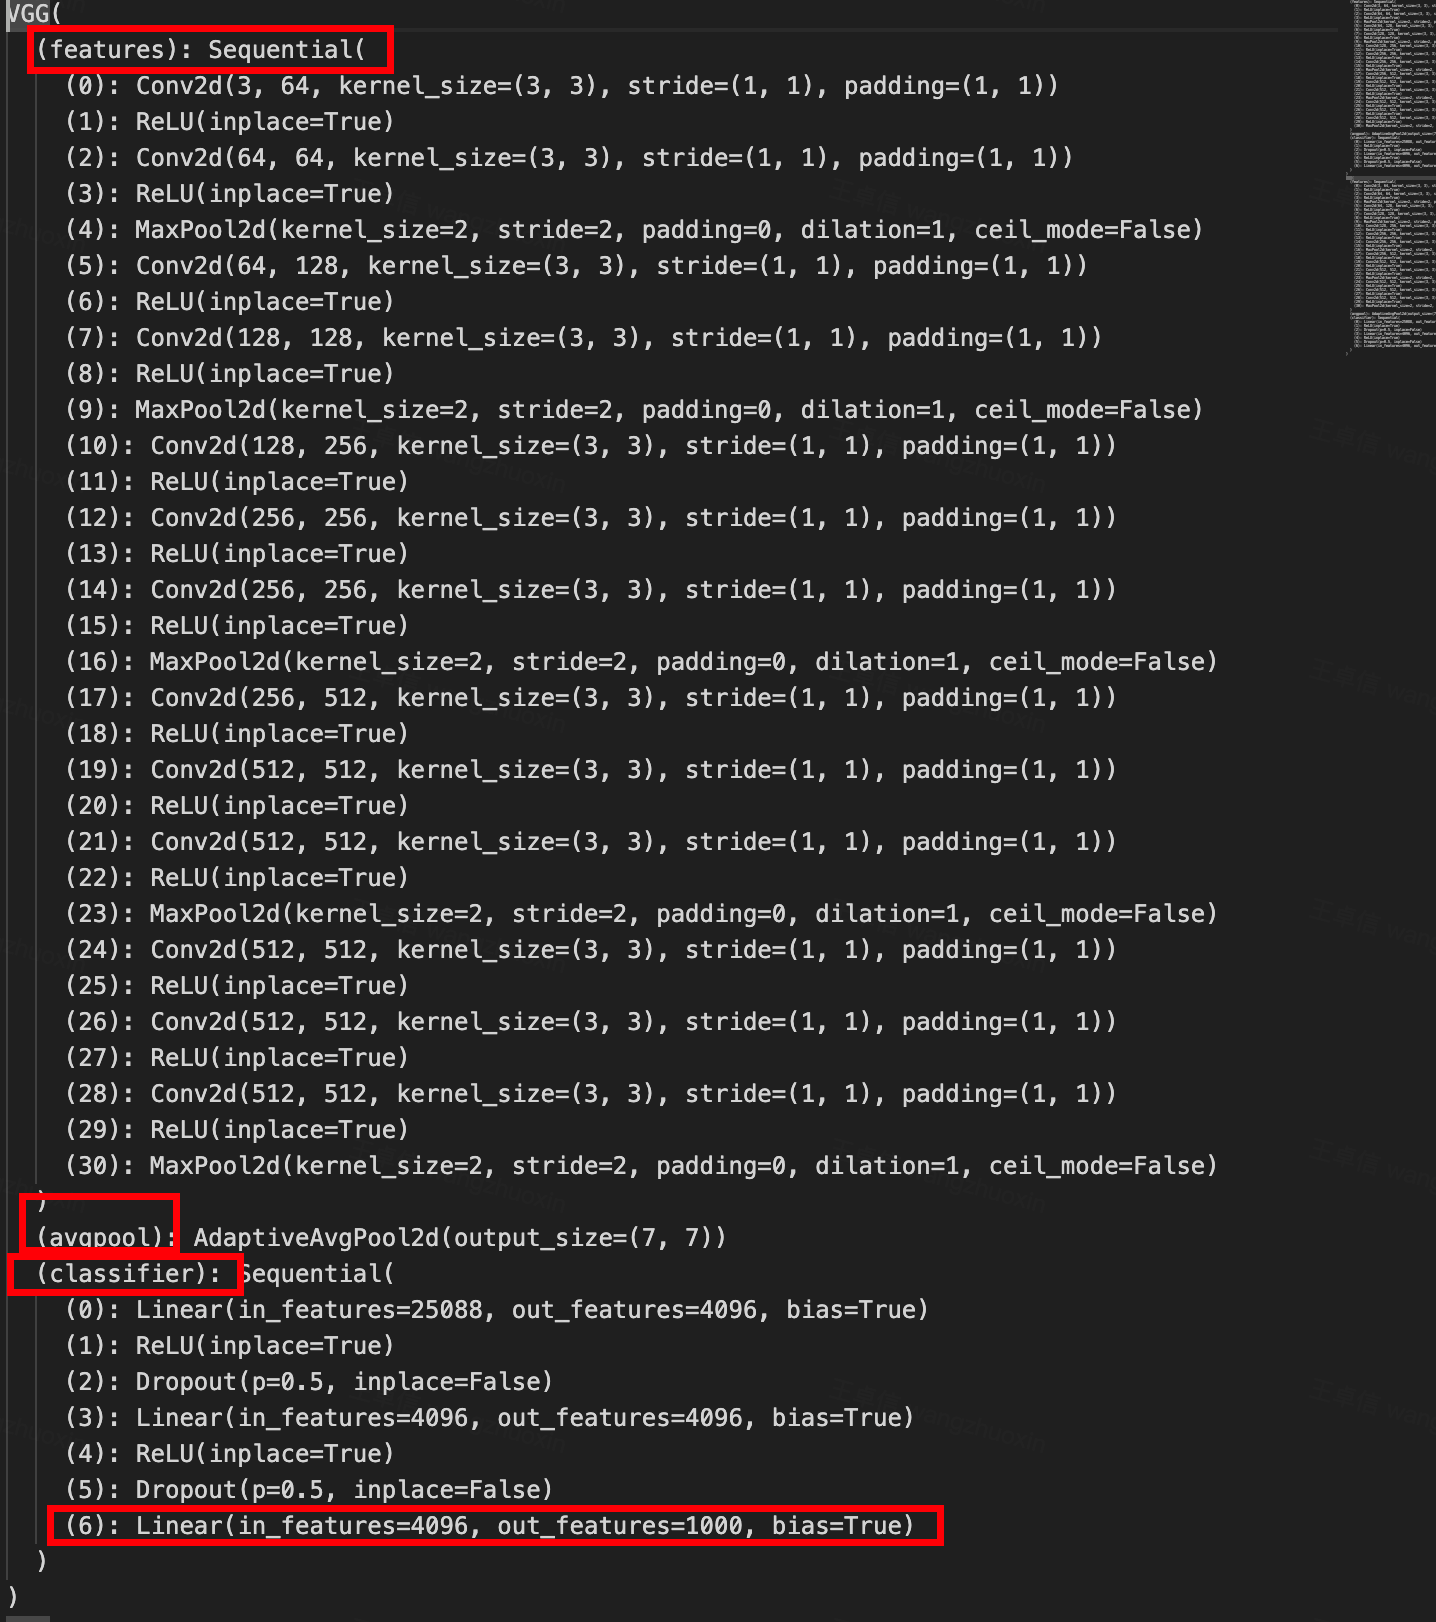

网络分为三大块：features、avgpool、classifier。
下面改的是，classifier的(6)

In [ ]:
import torchvision
from torch import nn

vgg16_false = torchvision.models.vgg16(pretrained=False) # 没有预训练的参数     
print(vgg16_false)

vgg16_false.classifier[6] = nn.Linear(4096,10)
print(vgg16_false)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1